In [1]:
import numpy as np
import pandas as pd

from numba import jit, prange, njit
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from pyscarcopula.src.Frank.FrankCopula  import ArchimedianCopula
from pyscarcopula.src.Gumbel.GumbelCopula  import GumbelCopula
from pyscarcopula.src.Joe.JoeCopula  import JoeCopula

from pyscarcopula.auxiliary.funcs import jit_pobs, pobs
import math
from scipy.optimize import minimize, Bounds

from typing import Literal


In [2]:
moex_data = pd.read_csv("data/moex_top.csv", index_col=0)
#tickers = ['AFLT', 'LSRG', 'GAZP', 'NLMK']
tickers = ['AFLT', 'LSRG', 'GAZP', 'NLMK', 'ROSN', 'KMAZ', 'AFKS', 'BSPB', 'MGNT']

moex_returns_pd = np.log(moex_data[tickers] / moex_data[tickers].shift(1))[1:601]
moex_returns = moex_returns_pd.values
pobs_data = pobs(moex_returns)


count_instruments = len(tickers)
copula = JoeCopula(count_instruments)

In [3]:
@jit(nopython=True, parallel = True, cache = True)
def p_sampler_ou(alpha, dwt, init_state = None):
    #alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    theta, mu, nu = alpha[0], alpha[1], alpha[2]

    T = len(dwt)
    dt = 1 / T
    xt = np.zeros(dwt.shape)
    #mu = -alpha1 / alpha2
    if init_state is None:
        xt[0] = mu
    else:
        xt[0] = init_state
    for k in range(1, T):
        A = -theta * (xt[k - 1] - mu)
        B = nu
        xt[k] = xt[k - 1] + A * dt + B * dwt[k]
    return xt

@jit(nopython = True, cache = True, parallel = True)
def get_avg_p_log_likelihood_ou(data, lambda_data, latent_process_tr, pdf, transform):
    avg_likelihood = 0
    copula_log_data = np.zeros(latent_process_tr)

    for k in prange(0, latent_process_tr):
        copula_log_data[k] = np.sum(np.log(np.maximum(pdf(data, transform(lambda_data[:,k])), 1e-100)))

    '''trick for calculation large values. calculate e^(sum(log_cop) - corr) instead of e^(sum(log_cop)).
    Do inverse correction at the end of calculations'''
    corr = max(copula_log_data)
    avg_likelihood = np.sum(np.exp(copula_log_data - corr)) / latent_process_tr
    return math.log(avg_likelihood) + corr


@jit(nopython = True, cache = True)
def p_jit_mlog_likelihood_ou(alpha: np.array, data: np.array, dwt: np.array, latent_process_tr: int,
                      print_path: bool, pdf: callable, transform: callable, init_state: np.array = None) -> float:
    
    '''initial data check'''
    if np.isnan(np.sum(alpha)) == True:
        res = 10000
        if print_path == True:
            print(alpha, 'incorrect params', res)
        return res
    
    lambda_data = p_sampler_ou(alpha, dwt, init_state)
    avg_log_likelihood = get_avg_p_log_likelihood_ou(data.T, lambda_data, latent_process_tr, pdf, transform)
    res = - avg_log_likelihood
    if np.isnan(res) == True:
        if print_path == True:
            print(alpha, 'unknown error', res)
    else:
        if print_path == True:
            print(alpha, res)
    return res


In [4]:
@jit(nopython=True, cache = True)
def moving_average(a, n = 3):
    ret = np.cumsum(a)
    ret[n:] = ret[n:] - ret[:-n]
    ret = ret[n - 1:] / n
    lin_arr1 = np.linspace(a[0], ret[0], n//2)
    index = len(a) - (len(lin_arr1) + len(ret))
    lin_arr2 = np.linspace(ret[-1], a[-1], index)
    ret = np.concatenate((lin_arr1, ret, lin_arr2 ))
    return ret

@jit(nopython=True, cache = True)
def poly_fit(x, y, dim, fit_intercept = True, ridge_alpha = 0.0):
    '''least squares fit y = f(x), where f(x) - polynom with dimension = dim'''
    fi = int(fit_intercept)
    A = np.zeros((len(x), dim + fi))
    x_i = x
    for i in range(0, dim):
        #A[:,i + fi] = x**(i + 1)
        A[:,i + fi] = x_i
        x_i = x_i  * x
    if fit_intercept == True:
        A[:,0] = np.ones(len(x))
    res = linear_least_squares(A, y, ridge_alpha)
    return res

@jit(nopython=True, cache = True)
def poly(data, coef, intercept = True):
    '''returns polynom of data (c0 + c1 t + c2 t^2 + ...) with coeficients = coef. 
    If intercept == True: first coef considered as free parameter c0; Otherwise - as c1.'''
    dim = len(coef)
    res = np.zeros(len(data))
    fi = int(intercept)
    for i in range(0, dim):
        res += coef[i] * data**(1 - fi + i)
    return res



@jit(nopython=True, cache = True)
def bounded_polynom_fit(x, y, dim, type: Literal['two-sided', 'left-sided', 'right-sided', 'no bounds'], ridge_alpha = 0.0):
    if type == 'two-sided':
        x0 = x[0]
        x1 = x[-1]
        y0 = y[0]
        y1 = y[-1]
        c0 = (y0 * x1 - y1 * x0) / (x1 - x0)
        c1 = (y1 - y0) / (x1 - x0)
        d1 = -x0 - x1
        d2 = x0 * x1
        A = np.zeros((len(x), dim))
        x_i = np.ones(len(x))
        for i in range(0, dim):
            A[:,i] = x_i * x * x + d1 * x_i * x + d2 * x
            x_i = x_i  * x
        A[:,0] += np.ones(len(x)) * c0
        A[:,1] += x * c1
        res = linear_least_squares(A, y, ridge_alpha)
        return res
    elif type == 'no bounds':
        fi = 1
        A = np.zeros((len(x), dim + fi))
        x_i = x
        for i in range(0, dim):
            A[:,i + fi] = x_i
            x_i = x_i  * x
        A[:,0] = np.ones(len(x))
        res = linear_least_squares(A, y, ridge_alpha)
        return res
    elif type == 'left-sided':
        x0 = x[0]
        y0 = y[0]
        A = np.zeros((len(x), dim))
        x_i = np.ones(len(x))
        for i in range(0, dim):
            A[:,i] = x_i * (x - x0)
            x_i = x_i  * x
        res = linear_least_squares(A, y - y0, ridge_alpha)
        return res
    elif type == 'right-sided':
        x0 = x[-1]
        y0 = y[-1]
        A = np.zeros((len(x), dim))
        x_i = np.ones(len(x))
        for i in range(0, dim):
            A[:,i] = x_i * (x - x0)
            x_i = x_i  * x
        res = linear_least_squares(A, y - y0, ridge_alpha)
        return res
    else:
        raise ValueError(f"type = {type} not implemented")


@jit(nopython=True, cache = True)
def bounded_polynom(x, y, coef, type: Literal['two-sided', 'left-sided', 'right-sided', 'no bounds']):
    if type == 'two-sided':
        dim = len(coef)
        x0 = x[0]
        x1 = x[-1]
        y0 = y[0]
        y1 = y[-1]
        c0 = (y0 * x1 - y1 * x0) / (x1 - x0)
        c1 = (y1 - y0) / (x1 - x0)
        d1 = -x0 - x1
        d2 = x0 * x1
        res = np.zeros(len(x))
        x_i = np.ones(len(x))
        for i in range(0, dim):
            res += coef[i] * x_i
            x_i = x_i * x
        return (x * x + d1 * x + d2) * res + c1 * x + c0
    elif type == 'no bounds':
        dim = len(coef)
        res = np.zeros(len(x))
        fi = 1
        for i in range(0, dim):
            res += coef[i] * x**(1 - fi + i)
        return res
    elif type == 'left-sided':
        dim = len(coef)
        x0 = x[0]
        y0 = y[0]
        res = np.zeros(len(x))
        x_i = np.ones(len(x))
        for i in range(0, dim):
            res += coef[i] * (x - x0) * x_i
            x_i = x_i * x
        return res + y0
    elif type == 'right-sided':
        dim = len(coef)
        x0 = x[-1]
        y0 = y[-1]
        res = np.zeros(len(x))
        x_i = np.ones(len(x))
        for i in range(0, dim):
            res += coef[i] * x_i
            x_i = x_i * x
        return y0 + (x - x0) * res
    else:
        raise ValueError(f"type = {type} not implemented")


@jit(nopython=True, cache = True)
def mod_abs(x):
    b = 1
    #res = x * (2 / (1 + np.exp(-b * x)) - 1)
    res = x * np.tanh(b * x)
    return res

@jit(nopython=True, cache = True)
def poly_corr(t_data, coef, alpha, intercept):
    '''correct polynom fit result to be below a threshold that raises from norm constant'''
    res = poly(t_data, coef, intercept)
    alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    sigma2 = alpha3**2 / (- 2 * alpha2) * (1 - np.exp(2 * alpha2 * t_data)) + 0.0001
    #max_res = 1 / (2 * sigma2[-1]) - 0.5
    max_res = 1 / (2 * sigma2) - 0.0
    #max_res = 0.0
    exp_res = np.exp(-0.5*(max_res - res))
    return 1 / (1 + exp_res) * res
    #return -(mod_abs(max_res - res) - max_res - res) / 2


@jit(nopython=True, cache = True)
def correction(t_data, x_data, alpha):
    #alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    theta, mu, nu = alpha[0], alpha[1], alpha[2]
    sigma2 = nu**2 / (2 * theta) * (1 - np.exp(-2 * theta * t_data)) + 0.0001
    max_res = 1 / (2 * sigma2) - 0.1
    exp_res = np.exp(-0.5*(max_res - x_data))
    return 1 / (1 + exp_res) * x_data
    #max_res = 0.0
    #return -(mod_abs(max_res - x_data) - max_res - x_data) / 2


def alpha_params(alpha):
    alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    mu = -alpha1 / alpha2
    theta = -alpha2
    nu = alpha3  
    D = nu**2/2
    print(f'alpha1 = {alpha1}, alpha2 = {alpha2}, alpha3 = {alpha3}')
    print(f'theta = {theta}, mu = {mu}, nu = {nu}, D = {D}')


In [5]:
@jit(nopython=True, cache = True)
def log_norm_ou(alpha: np.array, a1: np.array, a2: np.array, t: np.array, x0: np.array):
    #alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    theta, mu, nu = alpha[0], alpha[1], alpha[2]
    # mu = -alpha1 / alpha2
    # theta = -alpha2
    # nu = alpha3
    D = nu**2/2
    sigma2 = D/theta * (1 - np.exp(-2 * theta * t))
    #xs = mu + x0 * np.exp(alpha2 * t)
    xs = (x0 - mu) * np.exp(-theta * t) + mu
    res = (a1**2 * sigma2 + 2 * a1 * xs + 2 * a2 * xs**2) / (2 - 4 * a2 * sigma2) - 0.5 * np.log(1 - 2*a2*sigma2) #np.log1p(-2 * a2 * sigma2)
    return res

@jit(nopython=True, cache = True)
def m_sampler_ou(alpha, a1t, a2t, dwt, init_state = None):
    #alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    theta, mu, nu = alpha[0], alpha[1], alpha[2]

    T = len(dwt)
    dt = 1 / T
    xt = np.zeros(dwt.shape)
    # mu = -alpha1 / alpha2
    # theta = -alpha2
    # nu = alpha3
    D = nu**2 / 2
    if init_state is None:
        xt[0] = mu
    else:
        xt[0] = init_state
    for i in range(1, T):
        a1, a2 = a1t[i], a2t[i]
        a1dt, a2dt =  (a1t[i] - a1t[i - 1]) / dt, (a2t[i] - a2t[i - 1]) / dt
        #a1dt, a2dt = 0, 0
        t = i/T
        sigma2 = D / theta * (1 - np.exp(- 2 * theta * t))
        p = (1 - 2 * a2 * sigma2)
        sigma2w = sigma2 / p
        #xs = mu + xt[0] * np.exp(-theta * t)
        xs = (xt[0] - mu) * np.exp(-theta * t) + mu
        xsw = (xs + a1 * sigma2) / p
        sigma2dt = nu**2 - 2 * theta * sigma2
        sigma2wdt = (sigma2dt + 2 * sigma2**2 * a2dt) / p**2
        xsdt = -theta * (xs - mu)
        xswdt = (xsdt + a1 * sigma2dt + a1dt * sigma2) / p + 2 * xsw * (a2dt * sigma2 + a2 * sigma2dt) / p
        var = nu**2 / ( 1 - 2 * nu**2 * a2)
        B = nu #* np.sqrt( 1 - 2 * nu**2 * a2)
        A = xswdt - (xt[i - 1] - xsw) * (B**2 - sigma2wdt) / (2 * sigma2w)
        xt[i] = xt[i - 1] + A * dt + B * dwt[i]
    return xt

In [6]:
@jit(nopython=True, cache = True)
def ffit(x, y, dim, fit_intercept = True, ridge_alpha = 0.0):
    '''least squares fit y = f(x), where f(x) - polynom with dimension = dim'''
    fi = int(fit_intercept)
    A = np.zeros((len(x), 2 * dim + fi))
    for i in range(0, dim):
        n = 2 * i + fi
        #A[:,i + fi] = x**(i + 1)
        A[:,n] = np.sin(n * x)
        A[:,n + 1] = np.cos(n * x)
    if fit_intercept == True:
        A[:,0] = np.ones(len(x))
    res = linear_least_squares(A, y, ridge_alpha)
    return res


@jit(nopython=True, cache = True)
def ffdata(data, coef, intercept = True):
    '''returns polynom of data (c0 + c1 t + c2 t^2 + ...) with coeficients = coef. 
    If intercept == True: first coef considered as free parameter c0; Otherwise - as c1.'''
    dim = len(coef)
    res = np.zeros(len(data))
    fi = int(intercept)
    for i in range(0, (dim - fi)/2):
        n = 2 * i + fi
        res += coef[n] * np.sin(n * data)
        res += coef[n+1] * np.cos(n * data)
    res += coef[0]
    return res


In [6]:
#@jit(nopython=True, cache = True, parallel = True)
def m_jit_mlog_likelihood_ou(alpha, data, dwt, latent_process_tr, m_iters, print_path, 
                             pdf, transform, init_state = None, fit_dim = 2, rigde_alpha = 0.0):
    T = len(data)
    norm_log_data = np.zeros((T, latent_process_tr))
    dt = 1/T
    t_data = np.linspace(0, 1, T)
    a_data = np.zeros((T, 3))
    #alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    theta, mu, nu = alpha[0], alpha[1], alpha[2]

    # mu = - alpha1 / alpha2
    # nu = alpha3
    # theta = -alpha2
    a1t = np.zeros(T)
    a2t = np.zeros(T)
    #res = np.zeros(m_iters)
    for j in range(0, m_iters):
        if j == 0:
            lambda_data = p_sampler_ou(alpha, dwt, init_state)
        else:
            lambda_data = m_sampler_ou(alpha, a1t, a2t, dwt, init_state)
            if np.isnan(np.sum(lambda_data)) == True:
                res = 10000
                if print_path == True:
                    print(alpha, 'm sampler nan', res)
                return res
        norm_log_data = np.zeros((T, latent_process_tr))
        a_mean = np.zeros(3)
        a_mean[0] = np.mean(a_data[:,0])
        a_mean[1] = np.mean(a_data[:,1])
        a_mean[2] = np.mean(a_data[:,2])
        a_data = np.zeros((T, 3))
        a_data[-1] = a_mean
        #for i in range(1, T):
        for i in range(T - 1, 0 , -1):
            copula_log_data = np.log(np.maximum(pdf(data[i], transform(lambda_data[i])), 1e-100))
            A = np.dstack( ( np.ones(latent_process_tr) , (lambda_data[i] - 0 * mu) , (lambda_data[i] - 0 * mu)**2 ) )[0]
            #A = np.dstack( ( np.ones(latent_process_tr) , (lambda_data[i] - 0 * mu) ) )[0]
            #b = copula_log_data + norm_log_data[i - 1]
            #if i == T - 1:
            norm_log_data[i] = log_norm_ou(alpha, a_data[i][1], a_data[i][2], dt, lambda_data[i - 1])
            print(norm_log_data[i])
            b = copula_log_data + norm_log_data[i]
            sigma2 = nu**2 / (2 * theta) * (1 - np.exp(-2 * theta * (t_data[i])))
            xs = mu + (np.mean(lambda_data[i - 1]) - mu) * np.exp(-theta * t_data[i])
            #model = sm.OLS(b, A)
            #results = model.fit(cov_type='HC0')
            try:
                #r = 1/(j + 1)**2
                
                s2 = sigma2#nu**2/(2 * np.abs(theta))
                #r = 1/np.sqrt(2 * np.pi * s2 ) * np.exp(-xs**2/(2 * s2))
                r = 0.0
                #r = 1/(2 * sigma2)
                #r = nu**2 / (2 * theta) * (1 - np.exp(-2 * theta))
                a_data[i - 1] = linear_least_squares(A, b, r) #1/1000 * (a_data[i][1] - a_data[i][2])**2 / (1 + a_data[i][1]**2 + a_data[i][2]**2)
                #a_data[i - 1] = results.params
                #print(i, j, results.rsquared, a_data[i - 1])

                #a_data[i - 1][1] = np.minimum(a_data[i - 1][1], 0.0)
                a_data[i - 1][2] = np.minimum(a_data[i - 1][2], 1/(2 * sigma2))
                #a_data[i - 1][2] = np.minimum(a_data[i - 1][2], 0.0) #1/(2 * sigma2)
                

                # Fit the model with heteroskedasticity-robust standard errors (HC3)
                
                
                # if i != T - 1:
                #     a_data[i - 1][1] = np.minimum(2 * np.abs(a_data[i - 1][1]), np.abs(a_data[i][1])) * np.sign(a_data[i][1])
                #a_data[i - 1] = np.maximum(np.minimum(a_data[i - 1], 3000),-3000)
            except:
                res = 10000
                if print_path == True:
                    print(alpha, 'ls problem fail', res, i)
                return res
            #norm_log_data[i] = log_norm_ou(alpha, a_data[i][1], a_data[i][2], dt, lambda_data[i - 1])
            #norm_log_data[i - 1] = log_norm_ou(alpha, a_data[i - 1][1], a_data[i - 1][2], dt, lambda_data[i - 1])
        a_data_a1 = a_data[:,1].copy()
        a_data_a2 = a_data[:,2].copy()
        val = np.minimum(np.mean(a_data_a2), 0)
        if a_data_a2[-1] > val:
            a_data_a2[-1] = val

        intercept = True
        
        # a1_params = poly_fit(t_data, a_data_a1, dim = j, fit_intercept = intercept)
        # a2_params = poly_fit(t_data, a_data_a2, dim = j, fit_intercept = intercept)
        # a1t = poly(t_data, a1_params, intercept = intercept)
        # a2t = poly_corr(t_data, a2_params, alpha, intercept = intercept)
        #a2t = poly(t_data, a2_params, intercept = False)

        fit_type1 = 'no bounds'
        fit_type2 = 'right-sided'
        dim = j + 1
        #dim = 2
        
        a1_params = bounded_polynom_fit(t_data, a_data_a1, dim = dim, ridge_alpha = 0.0, type = fit_type1)
        a1t = bounded_polynom(t_data, a_data_a1, a1_params, type = fit_type1)

        rigde_alpha_list = np.array([0.05, 0.1, 0.5, 1.0, 5.0, 10.0])
        for r in rigde_alpha_list:
            a2_params = bounded_polynom_fit(t_data, a_data_a2, dim = dim, ridge_alpha = r, type = fit_type2)
            a2t = bounded_polynom(t_data, a_data_a2, a2_params, type = fit_type2)
            bound_check = check_a2_bounds(alpha, a2t, t_data)
            if bound_check == True:
                print(r)
                break
            else:
                continue
        if r == rigde_alpha_list[-1]:
            a2t = correction(t_data, a2t, alpha)
        
        #a2t = correction(t_data, a2t, alpha)

        # a1_params = ffit(t_data, a_data_a1, dim = fit_dim, ridge_alpha = 1.0)
        # a2_params = ffit(t_data, a_data_a2, dim = fit_dim, ridge_alpha = 1.0)

        # a1t = ffdata(t_data, a1_params)
        # a2t = ffdata(t_data, a2_params)
        # a2t = correction(t_data, a2t, alpha)
    # a1t = 0 * a1t
    # a2t = 0 * a2t

    log_likelihood = np.zeros(latent_process_tr)
    lambda_data = m_sampler_ou(alpha, a1t, a2t, dwt, init_state)
    for i in range(T - 1, 0, -1):
        a1, a2 = a1t[i], a2t[i]
        norm_log_data[i] = log_norm_ou(alpha, a1, a2, dt, lambda_data[i - 1])
    norm_log_data[0] = log_norm_ou(alpha, a1t[0], a2t[0], dt, lambda_data[0])

    for k in range(0, latent_process_tr):
        copula_log_data = np.log(np.maximum(pdf(data.T, transform(lambda_data[:,k]) ), 1e-100))
        g = (a1t * (lambda_data[:,k] - 0 * mu)  + a2t * (lambda_data[:,k] - 0 * mu)**2)
        log_likelihood[k] = np.sum(copula_log_data + norm_log_data[:,k] - g)
    xc = np.max(log_likelihood)
    avg_likelihood = np.sum(np.exp(log_likelihood - xc)) / latent_process_tr
    res = np.log(avg_likelihood) + xc
    res = -res
    # if (j > 0 and res[j - 1] < 0 and res[j] > 0) or np.isnan(res[j]) == True:
    #     res[-1] = p_jit_mlog_likelihood_ou(alpha, data, dwt, latent_process_tr, False, pdf, transform, init_state)
    #     if print_path == True:
    #         print(res)
    #         print(alpha, 'instability encountered. return to p sampler', res[-1])
    #     return a_data
    #     return res[-1]
    if print_path == True:
        print(alpha, res)
    print(r)
    return a_data


In [7]:
@jit(nopython=True, cache = True)
def check_a2_bounds(alpha, x, t):
    theta, mu, nu = alpha[0], alpha[1], alpha[2]
    sigma2 = nu**2 / (2 * theta) * (1 - np.exp(-2 * theta * t))
    ub = 1/(2 * sigma2 + 0.001)
    bound_check = True
    for k in range(0, len(x)):
        if x[k] >= ub[k]:
            bound_check = False
            return bound_check
    return bound_check

In [8]:
# @jit(nopython=True, cache = True)
# def linear_least_squares(matA: np.array, matB: np.array, alpha) -> np.array:
#     '''Ridge regression
#        Input  Ax = b
#        Output x = (A.T * A + alpha * I) ^ (-1) * A.T * b
#     '''
#     I = np.identity(len(matA[0]))
#     I[0][0] = 0
#     return np.linalg.inv( matA.T @ matA + alpha * I) @ matA.T @ matB 
#     #return np.linalg.pinv(matA) @ matB

@jit(nopython=True, cache = True)
def linear_least_squares(matA: np.array, matB: np.array, ridge_alpha = 0.0, pseudo_inverse = False) -> np.array:
    '''Ridge regression
       Input  Ax = b
       Output x = (A.T * A + alpha * I)^(-1) * A.T * b

       Solution with pseudoinverse matrix:
       Input Ax = b
       Output x = A^(+) * b
       where A^(+) - pseudoinverse matrix
    '''
    if pseudo_inverse == False:
        I = np.identity(len(matA[0]))
        I[0][0] = 0
        result = np.linalg.inv(matA.T @ matA + ridge_alpha * I) @ matA.T @ matB
    else:
        result = np.linalg.pinv(matA) @ matB
    return result

In [41]:
A = np.array([
    [1.0, 2.3, 3.3],
    [1.0, 2.13, 3.03],
    [1.0, 2.003, 3.13],
    [1.0, 2.4, 3.03],
    [1.0, 2.35, 3.11],
    [1.0, 2.43, 3.43],
])
b = np.array([2.4, 2.2, 2.3, 2.25, 2.34, 2.31])

In [45]:
A.T @ A

array([[ 6.      , 13.613   , 19.03    ],
       [13.613   , 31.026309, 43.22869 ],
       [19.03    , 43.22869 , 60.4857  ]])

In [43]:
np.linalg.pinv( A.T @ A) @ A.T @ b 

array([1.4478602 , 0.01084692, 0.26091328])

In [44]:
np.linalg.inv( A.T @ A) @ A.T @ b 

array([1.4478602 , 0.01084692, 0.26091328])

In [42]:
linear_least_squares(A, b, 0.0)

array([1.4478602 , 0.01084692, 0.26091328])

In [11]:
i = 0
data = pobs(moex_returns[0 + i:250 + i])
T = len(data)
latent_process_tr = 500

In [762]:
T = len(data)
#s = np.random.randint(0, 100000)
s = 25400
rng = np.random.RandomState(seed=s)
dwt = rng.normal(0, 1, size = (len(pobs_data), latent_process_tr)) * np.sqrt(1/T)
dwt = dwt[i:len(data) + i]

In [ ]:
#bounds = Bounds([-700., -700, 0.0], [700, 700, 700])
latent_process_tr = 500
data = pobs_data[0:250]

alpha = np.array([20.40351061, 0.49428505, 0.47159938])


constr = {'type': 'ineq', 'fun': lambda x: np.abs(x[1]) - x[2]**2 - 0.001}

log_min = minimize(m_jit_mlog_likelihood_ou, alpha,
                            args=(data, dwt, latent_process_tr, 5, True, copula.np_pdf(), copula.transform, init_state),
                            method='SLSQP',
                            #bounds = bounds,
                            #constraints = constr,
                            options={'ftol': 1e-4} )
log_min

In [19]:
#@jit(nopython=True, cache = True, parallel = True)
def m_jit_mlog_likelihood_ou(alpha, data, dwt, latent_process_tr, m_iters, print_path, 
                             pdf, transform, init_state = None):
    T = len(data)
    norm_log_data = np.zeros((T, latent_process_tr))
    dt = 1/T
    t_data = np.linspace(0, 1, T)
    a_data = np.zeros((T, 3))
    theta, mu, nu = alpha[0], alpha[1], alpha[2]
    a1t = np.zeros(T)
    a2t = np.zeros(T)
    for j in range(0, m_iters):
        if j == 0:
            lambda_data = p_sampler_ou(alpha, dwt, init_state)
        else:
            lambda_data = m_sampler_ou(alpha, a1t, a2t, dwt, init_state)
            if np.isnan(np.sum(lambda_data)) == True:
                res = 10**10
                if print_path == True:
                    print(alpha, 'm sampler nan', res)
                return res
        norm_log_data = np.zeros((T, latent_process_tr))
        a_mean = np.zeros(3)

        a_mean[0] = np.mean(a_data[:,0])
        a_mean[1] = np.mean(a_data[:,1])

        sigma2 = nu**2 / (2 * theta) * (1 - np.exp(-2 * theta))
        ub = np.maximum(1/(2 * sigma2) - 0.1, 0)
        a_mean[2] = np.minimum(np.mean(a_data[:,2]), ub)

        a_data = np.zeros((T, 3))
        a_data[-1] = a_mean
        for i in range(T - 1, 0 , -1):
            copula_log_data = np.log(np.maximum(pdf(data[i], transform(lambda_data[i])), 1e-100))
            A = np.dstack( ( np.ones(latent_process_tr) , (lambda_data[i] - 0 * mu) , (lambda_data[i] - 0 * mu)**2 ) )[0]
            norm_log_data[i] = log_norm_ou(alpha, a_data[i][1], a_data[i][2], dt, lambda_data[i - 1])

            b = copula_log_data + norm_log_data[i]
            #print(norm_log_data[i])
            sigma2 = nu**2 / (2 * theta) * (1 - np.exp(-2 * theta * (t_data[i])))
            #r = sigma2
            r = 0.0
            ub = np.maximum(1/(2 * sigma2) - 0.1, 0)
            #ub = 0.0
            a_data[i - 1] = linear_least_squares(A, b, r, pseudo_inverse = True)

            # try:
            #     a_data[i - 1] = linear_least_squares(A, b, r)
            # except:
            #     try:
            #         a_data[i - 1] = linear_least_squares(A, b, r, pseudo_inverse = True)
            #     except:
            #         res = 10**10
            #         if print_path == True:
            #             print(alpha, 'ls problem fail', res, i)
            #         return res
            a_data[i - 1][2] = np.minimum(a_data[i - 1][2], ub)
            #a_data[i - 1] = np.maximum(np.minimum(a_data[i - 1], 3000),-3000)

        a_data_a1 = a_data[:,1].copy()
        a_data_a2 = a_data[:,2].copy()

        val = np.minimum(np.mean(a_data_a2), 0)
        if a_data_a2[-1] > val:
            a_data_a2[-1] = val

        fit_type1 = 'no bounds'
        fit_type2 = 'right-sided'
        dim = j + 1
        #dim = 2

        a1_params = bounded_polynom_fit(t_data, a_data_a1, dim = dim, ridge_alpha = 0.0, type = fit_type1)
        a1t = bounded_polynom(t_data, a_data_a1, a1_params, type = fit_type1)

        rigde_alpha_list = np.array([0.0, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0])
        for r in rigde_alpha_list:
            a2_params = bounded_polynom_fit(t_data, a_data_a2, dim = dim, ridge_alpha = r, type = fit_type2)
            a2t = bounded_polynom(t_data, a_data_a2, a2_params, type = fit_type2)
            bound_check = check_a2_bounds(alpha, a2t, t_data)
            if bound_check == True:
                print(r)
                break
            else:
                continue
        if r == rigde_alpha_list[-1]:
            print(r)
            a2t = correction(t_data, a2t, alpha)

    log_likelihood = np.zeros(latent_process_tr)
    lambda_data = m_sampler_ou(alpha, a1t, a2t, dwt, init_state)
    for i in range(T - 1, 0, -1):
        a1, a2 = a1t[i], a2t[i]
        norm_log_data[i] = log_norm_ou(alpha, a1, a2, dt, lambda_data[i - 1])
    norm_log_data[0] = 0 * log_norm_ou(alpha, a1t[0], a2t[0], dt, lambda_data[0])

    for k in range(0, latent_process_tr):
        copula_log_data = np.log(np.maximum(pdf(data.T, transform(lambda_data[:,k])), 1e-100))
        g = (a1t * (lambda_data[:,k] - 0 * mu)  + a2t * (lambda_data[:,k] - 0 * mu)**2)
        g[0] = 0
        log_likelihood[k] = np.sum(copula_log_data + norm_log_data[:,k] - g)
        #print(norm_log_data[:,k][0:10], g[0:10])
    xc = np.max(log_likelihood)
    avg_likelihood = np.sum(np.exp(log_likelihood - xc)) / latent_process_tr
    res = np.log(avg_likelihood) + xc
    res = -res
    if print_path == True:
        print(alpha, res)
    return a_data


In [12]:
s = 25400
rng = np.random.RandomState(seed = s)
dt = 1.0/250
print(s)
dwt = rng.normal(0, 1, size = (T, latent_process_tr)) * np.sqrt(dt)
j = 121
data = pobs(moex_returns[0 + j:250 + j])

25400


In [12]:
alpha = np.array([-0.34741403 , 1.71949998 ,-0.14467107])
moex_returns_pd = np.log(moex_data[tickers] / moex_data[tickers].shift(1))[1:251]
moex_returns = moex_returns_pd.values
data = pobs(moex_returns)
s = 25400
rng = np.random.RandomState(seed= s)
dwt = rng.normal(0, 1, size = (len(data), 500)) * np.sqrt(1/len(data))
copula.mlog_likelihood(alpha, data, method='scar-m-ou', dwt = dwt)

-674.1621127601437

In [785]:
from pyscarcopula.sampler.sampler_ou import m_jit_mlog_likelihood_ou

In [91]:
#%%timeit
s = np.random.randint(0, 1000000)
#s = 25400
#s = 10
rng = np.random.RandomState(seed= s)
dwt = rng.normal(0, 1, size = (len(data), latent_process_tr)) * np.sqrt(1/len(data))
i = 0
#dwt = dwt[i:len(data) + i]

#alpha = np.array([-0.56395007,  2.59290612, -1.41567972])
#alpha = np.array([4.51551114, -0.41554241, -0.29707367])
#alpha = np.array([0.74446907,  0.69987999, -0.04472599])
#alpha = np.array([0.56390725, -0.61465765,  0.42402798])
#alpha = np.array([0.92330527,  0.22826444, -0.85666308])
#alpha = np.array([100.       ,    0.58042304 ,  1.55060208])
#alpha = np.array([-3.06908433,  1.030595,   -0.01905801])
alpha = np.array([-0.54018946,  0.85256699,  0.23002057])
#alpha = np.array([-0.47884225, 0.17273891,  0.16327304])
#alpha = np.array([4.62457538e+01, 5.53740378e-01, 5.49935376e-05])
#alpha = np.array([-0.34741403 , 1.71949998 ,-0.14467107])
#alpha = np.array([28.37437447,  0.71544573,  1.03712747])
#init_state = None
p_jit_mlog_likelihood_ou(alpha, data, dwt, latent_process_tr, True, copula.np_pdf(), copula.transform, init_state= None)


a_data = m_jit_mlog_likelihood_ou(alpha, data, dwt, latent_process_tr, 5, True, 
                                  copula.np_pdf(), copula.transform, init_state=None)

[-0.54018946  0.85256699  0.23002057] -129.61904355748663
0.0
0.0
0.0
0.0
0.0
[-0.54018946  0.85256699  0.23002057] -126.0007307429722


In [448]:
import re

file = open('lpdata.txt', 'r')
lines = file.readlines()
res = []
for i in range(0, len(lines)):
    l = lines[i]
    l0 = lines[i - 1]
    if l[0] == '=':
        l0 = l0.split(' ', 1)[1]
        splt = l0.split(' ')
        val = []
        for s in splt:
            if s != '':
                #j = re.findall(r'\d+\.\d+|\d+', s)[0]
                val.append(s)
        res.append(val)

In [451]:
states = np.array([[35.4199896, 0.6207818, 1.38475943],
 [59.88977275, 0.64447542, 1.4794832, ],
 [59.88990276, 0.6465662, 1.4551415, ],
 [59.88983166, 0.64485652, 1.41657613],
 [59.88897781, 0.64031144, 1.46775044],
 [59.88705281, 0.63550807, 1.54184342],
 [59.88705276, 0.63550745, 1.5418425, ],
 [59.88703819, 0.63388938, 1.54155465],
 [59.88693981, 0.6365439, 1.53717916],
 [59.88370203, 0.63049114, 1.61480937],
 [34.9915701, 0.61161816, 1.3897102, ],
 [34.98444044, 0.60661467, 1.41680881],
 [34.97872751, 0.6021607, 1.4455116, ],
 [34.9809121, 0.61067578, 1.48079215],
 [34.98254011, 0.61404473, 1.4995121, ],
 [34.98257329, 0.61292702, 1.49896988],
 [35.00349195, 0.61549339, 1.48108405],
 [35.02490549, 0.60987271, 1.44173227],
 [35.02493923, 0.61446168, 1.44186399],
 [35.02498102, 0.61350225, 1.44220707],
 [49.58998403, 0.61726948, 1.59214126],
 [49.58998005, 0.61831973, 1.59208212],
 [49.58981283, 0.6151152, 1.60882129],
 [49.58981929, 0.61364758, 1.60862059],
 [49.59062799, 0.61656404, 1.58789947],
 [49.59117708, 0.61897236, 1.6201598, ],
 [49.59118635, 0.61852582, 1.61996017],
 [49.59270693, 0.62010524, 1.57781848],
 [49.60395752, 0.62155566, 1.62079519],
 [49.60455886, 0.61347989, 1.66108546],
 [49.60487277, 0.60781831, 1.69435864],
 [49.60389519, 0.61048985, 1.68512431],
 [49.59780235, 0.61220041, 1.75142671],
 [49.59778215, 0.6133282, 1.75060447],
 [49.59667714, 0.6143856, 1.72683044],
 [49.59640147, 0.60771777, 1.70291808],
 [49.59639682, 0.60894549, 1.70305225],
 [49.5960519, 0.59693619, 1.66386989],
 [49.59604874, 0.59591979, 1.6642526, ],
 [49.59605769, 0.59492976, 1.66487387],
 [49.59605943, 0.59359768, 1.6648855, ],
 [49.59605919, 0.59188656, 1.66511769],
 [49.5960721, 0.59059952, 1.66456336],
 [49.59730811, 0.59015015, 1.64854102],
 [49.59730811, 0.5901501, 1.64854101],
 [49.61009675, 0.58929108, 1.59186255],
 [49.61173024, 0.58546418, 1.58278138],
 [49.62845462, 0.5872748, 1.54696737],
 [49.628467, 0.58683962, 1.54699747],
 [49.63050265, 0.57871507, 1.55975224],
 [49.63050265, 0.57871505, 1.55975225],
 [49.63327016, 0.58044766, 1.57807741],
 [49.65727448, 0.57526384, 1.53111213],
 [49.66605324, 0.5770732, 1.48585228],
 [49.66700145, 0.57853008, 1.47564541],
 [49.66701594, 0.57907368, 1.47587373],
 [49.666692, 0.57499835, 1.48846557],
 [49.65840694, 0.57709468, 1.432558, ],
 [49.65838477, 0.57810367, 1.43205637],
 [49.65675734, 0.58192134, 1.39695474],
 [49.6410345, 0.57729966, 1.49709668],
 [49.64019888, 0.57081642, 1.53610804],
 [49.64019718, 0.57055586, 1.53603752],
 [49.64020116, 0.57006698, 1.53581486],
 [49.63986195, 0.56764029, 1.5229864, ],
 [49.63986985, 0.56458734, 1.5333298, ],
 [49.63898099, 0.56187771, 1.57490753],
 [49.6380768, 0.5594991, 1.58063507],
 [49.63805543, 0.56092002, 1.58063072],
 [49.63788563, 0.56145952, 1.58146421],
 [49.63786331, 0.56042066, 1.58187015],
 [49.63785285, 0.55988127, 1.58171877],
 [49.6378265, 0.55966669, 1.58201779],
 [49.63595824, 0.56324207, 1.61369229],
 [49.63594746, 0.56295281, 1.61377829],
 [49.63591988, 0.56187172, 1.61283511],
 [28.8397433, 0.54772753, 1.27695602],
 [28.85315247, 0.54055679, 1.31518568],
 [28.85317526, 0.53850883, 1.31616896],
 [28.85374232, 0.53504274, 1.38307242],
 [28.88201568, 0.54629644, 1.34557727],
 [28.89751771, 0.5442575, 1.30030686],
 [28.89756997, 0.54321475, 1.29976678],
 [40.28010421, 0.54873406, 1.45928672],
 [40.28010359, 0.54975691, 1.45931934],
 [40.28819359, 0.54627058, 1.52393443],
 [40.28651945, 0.54725782, 1.5734961, ],
 [40.26856967, 0.55232899, 1.51369992],
 [40.2685344, 0.55067903, 1.51331928],
 [22.75749199, 0.53613359, 1.18615232],
 [22.75810997, 0.53165242, 1.16716739],
 [32.97975963, 0.53616035, 1.40513065],
 [12.71906828, 0.55169238, 0.5985893, ],
 [12.73259705, 0.54414532, 0.63551048],
 [25.36820044, 0.53497343, 1.25043244],
 [25.36766387, 0.54081741, 1.17183085],
 [25.35276688, 0.54880737, 1.10876889],
 [25.36336382, 0.53214528, 1.22901773],
 [44.71536994, 0.5506184, 1.47262107],
 [44.7153268, 0.56115051, 1.47299113],
 [44.71461744, 0.55600118, 1.48114223],
 [44.71461654, 0.55414932, 1.48113882],
 [44.71718475, 0.56177596, 1.3540717, ],
 [44.7156984, 0.55830993, 1.33900278],
 [44.71444989, 0.55376397, 1.37686492],
 [44.71443967, 0.55205938, 1.37684431],
 [44.7144367, 0.5508057, 1.37594096],
 [44.71397949, 0.55636647, 1.31165146],
 [44.71397478, 0.55596172, 1.31171301],
 [44.71386103, 0.55203167, 1.23935373],
 [4.44675031e+01, 6.12979751e-01, -5.53661365e-04],
 [4.54541405e+01, 7.15977037e-01, -8.89073395e-05],
 [4.54541405e+01, 7.15977037e-01, -8.89073395e-05],
 [4.54541405e+01, 7.15977037e-01, -8.89073395e-05]])

In [452]:
from pyscarcopula.metrics.latent_process import latent_process_sampler_one_step

In [525]:
s = 25400
rng = np.random.RandomState(seed = s)
window_len = 250
dt = 1.0/window_len
print(s)
dwt = rng.normal(0, 1, size = (len(moex_returns), latent_process_tr)) * np.sqrt(dt)

k = 110
dwt = dwt[k:window_len + k]
data = jit_pobs(moex_returns[k:window_len + k])

25400


In [523]:
init_state = np.array([0.45462978, 0.65841604, 0.49957597, 0.6939245, 0.57782605, 0.35695047,
                    0.56727667, 0.68892299, 0.51665231, 0.62716188, 0.55368901, 0.66878386,
                    0.47891837, 0.10925796, 0.4456712, 0.87977797, 0.69480122, 0.33427693,
                    0.2055531, 0.27407541, 0.55625553, 0.70519083, 0.70506806, 0.48153148,
                    0.49595699, 0.20414734, 0.69059148, 0.25957744, 0.59694146, 0.71381088,
                    0.31096479, 0.43670479, 0.53073107, 0.45747675, 0.54186281, 0.383836,
                    0.32584779, 0.39324153, 0.59101776, 0.29812358, 0.72751813, 0.58200302,
                    0.48129379, 0.45176677, 0.25901865, 0.44040939, 0.51710034, 0.72021913,
                    0.67436691, 0.73191358, 0.73411927, 0.67950823, 0.70031772, 0.32574499,
                    0.68263196, 0.67052264, 0.5594484, 0.33625231, 0.55138343, 0.29662621,
                    0.69633013, 0.56070672, 0.36218515, 0.56988326, 0.55120285, 0.59503359,
                    0.25747404, 0.75533971, 0.51074496, 0.6419287, 0.58972875, 0.48012605,
                    0.87611875, 0.61647034, 0.62010428, 0.60864566, 0.28926925, 0.7250424,
                    0.56265988, 0.7041161, 0.68975233, 0.51302207, 0.57478432, 0.41030309,
                    0.65952031, 0.34270565, 0.45941937, 0.600917, 0.39083057, 0.54829449,
                    0.6207265, 0.53116466, 0.57601426, 0.36388742, 0.41255006, 0.24716425,
                    0.40804766, 0.51176645, 0.52915277, 0.7701804, 0.69061902, 0.43090066,
                    0.73677571, 0.56504045, 0.56136562, 0.38824962, 0.46707594, 0.61644252,
                    0.7683555, 0.76954459, 0.61943177, 0.54484308, 0.68069919, 0.54547778,
                    0.54180746, 0.27373288, -0.04321562, 0.83978591, 0.58332765, 0.63099578,
                    0.27101534, 0.35761718, 0.4353827, 0.64212976, 0.66160872, 0.67924405,
                    0.58916756, 0.62035502, 0.62547411, 0.60344603, 0.58196622, 0.46847825,
                    0.21453174, 0.7500266, 0.38452358, 0.67529915, 0.57118142, 0.52077879,
                    0.49583738, 0.4320741, 0.59422172, 0.62556004, 0.82474892, 0.63520817,
                    0.75271362, 0.63022252, 0.42506337, 0.45801991, 0.6057089, 0.69073321,
                    0.50346462, 0.76749593, 0.18948788, 0.2846214, 0.55304624, 0.64681001,
                    0.4602526, 0.50350703, 0.55233328, 0.44953466, 0.49895247, 0.48471438,
                    0.51906418, 0.68821335, 0.61337805, 0.26870872, 0.62827682, 0.4952548,
                    0.73264344, 0.15969329, 0.85705116, 0.60696787, 0.72204414, 0.53466689,
                    0.64527177, 0.46556576, 0.54483749, 0.36318492, 0.88324709, 0.77113762,
                    0.55089066, 0.59670684, 0.63918764, 0.64531755, 0.47175828, 0.77970488,
                    0.80303385, 0.51022143, 0.40634902, 0.67900024, 0.58245532, 0.40598706,
                    0.42813661, 0.61981382, 0.6519909, 0.59090163, 0.47243632, 0.54178845,
                    0.63749754, 0.28771226, 0.98694781, 0.79509313, 0.58741286, 0.45558525,
                    0.43234871, 0.44885321, 0.65191788, 0.38509038, 0.45566097, 0.56477973,
                    0.54732051, 0.70318434, 0.37994814, 0.38858899, 0.75904168, 0.4165344,
                    0.82598725, 0.76681865, 0.78609807, 0.78544349, 0.28677516, 0.55347457,
                    0.41846817, 0.3569904, 0.84572501, 0.57843901, 0.63411359, 0.63217253,
                    0.52862354, 0.72281203, 0.24121251, 0.68202414, 0.82228698, 0.45368298,
                    0.44613426, 0.73637529, 0.45551754, 0.61632343, 0.67934249, 0.5315105,
                    0.49494289, 0.67135633, 0.44156625, 0.64200691, 0.7446018, 0.54505861,
                    0.53427692, 0.50969459, 0.3879467, 0.54574041, 0.48375211, 0.822831,
                    0.45241517, 0.49769931, 0.60057792, 0.37386299, 0.6599867, 0.4883655,
                    0.44005842, 0.43504732, 0.64381178, 0.45344114, 0.70821353, 0.81499651,
                    0.4360524, 0.47205241, 0.59507851, 0.58354858, 0.28380424, 0.28708267,
                    0.56963069, 0.55929916, 0.23109503, 0.51780239, 0.51299014, 0.52917385,
                    0.48974588, 0.45835735, 0.29436066, 0.70826333, 0.42851742, 0.77438932,
                    0.7451371, 0.67502603, 0.60510512, 0.63619853, 0.26347571, 0.51054499,
                    0.59720336, 0.54760796, 0.3149763, 0.50311044, 0.55189644, 0.55232165,
                    0.66125711, 0.49026919, 0.44928445, 0.78837336, 0.61969044, 0.41101632,
                    0.66832954, 0.40005021, 0.30851409, 0.32715498, 0.50449448, 0.74962335,
                    0.44215648, 0.49094573, 0.70087124, 0.72392026, 0.84170231, 0.29631449,
                    0.60747762, 0.46632551, 0.66430896, 0.43907942, 0.74190986, 0.50968179,
                    0.42887695, 0.49484003, 0.75063798, 0.48908676, 0.51267307, 0.57241045,
                    0.76884994, 0.57976774, 0.67759692, 0.60612879, 0.55468493, 0.45193773,
                    0.53681813, 0.50971549, 0.56142182, 0.66528727, 0.58833862, 0.50748937,
                    0.68588938, 0.33228036, 0.26783447, 0.612374, 0.52123567, 0.5900487,
                    0.61084318, 0.4130454, 0.39503, 0.41929938, 0.62715589, 0.6455471,
                    0.610593, 0.59069568, 0.53884375, 0.46530616, 0.7166093, 0.56710411,
                    0.49285201, 0.40412488, 0.59473434, 0.38410913, 0.51957195, 0.70519575,
                    0.3606982, 0.25618287, 0.33239141, 0.44725727, 0.6957901, 0.56155097,
                    0.44083468, 0.66412832, 0.39718155, 0.56227053, 0.6692393, 0.47620445,
                    0.72055486, 0.44804712, 0.87702017, 0.70844504, 0.40325925, 0.55448716,
                    0.22584516, 0.38963053, 0.27939597, 0.49476463, 0.57083791, 0.8015296,
                    0.57580326, 0.59658553, 0.45311196, 0.39331238, 0.7047594, 0.33509046,
                    0.53337047, 0.22929838, 0.26834712, 0.5703585, 0.65361148, 0.46633288,
                    0.52131108, 0.51670905, 0.62879961, 0.30731993, 0.53111327, 0.49314316,
                    0.66025538, 0.62060872, 0.54051432, 0.3360017, 0.68291392, 0.38603579,
                    0.47239861, 0.34342946, 0.7756529, 0.6849639, 0.38948038, 0.67480425,
                    0.36286443, 0.74113266, 0.6277443, 0.45462132, 0.33885658, 0.78885343,
                    0.55169363, 0.5866429, 0.57330735, 0.61201818, 0.51429671, 0.62109458,
                    0.37754323, 0.70172089, 0.2119973, 0.3718884, 0.68419495, 0.6719121,
                    0.43456892, 0.40992453, 0.54824261, 0.31963814, 0.73577984, 0.41287294,
                    0.62279117, 0.30510598, 0.5716562, 0.63786658, 0.52642123, 0.80659347,
                    0.68773206, 0.56521042, 0.77526109, 0.43315103, 0.49009163, 0.54927023,
                    0.41728463, 0.62124595, 0.52534045, 0.6045597, 0.53853473, 0.60849488,
                    0.48896005, 0.58518186, 0.4822185, 0.40856368, 0.55793301, 0.76608889,
                    0.47811907, 0.7715824, 0.67237719, 0.93602608, 0.32617331, 0.60858916,
                    0.57845021, 0.65035861, 0.69528178, 0.29623515, 0.48555258, 0.63747775,
                    0.54880999, 0.67835227, 0.44454226, 0.73575259, 0.4819214, 0.88368501,
                    0.48376473, 0.4058869, 0.69312358, 0.64257405, 0.7287451, 0.51310536,
                    0.30172334, 0.33133046, 0.51080671, 0.39728108, 0.45640819, 0.47388665,
                    0.48406736, 0.569478, 0.69562448, 0.69739669, 0.64304667, 0.69977156,
                    0.65560535, 0.4229335])

In [290]:
lp = 100000
dwt = np.random.normal(0, 1, size = (T, lp)) * np.sqrt(1/T)
p_jit_mlog_likelihood_ou(alpha, data, dwt, lp, True, copula.np_pdf(), copula.transform)


[ 0.92330527  0.22826444 -0.85666308] -162.31562461314218


-162.31562461314218

In [ ]:
bounds = Bounds([-10, -10, -10], [10, 10, 10])
latent_process_tr = 500
T = len(data)
s = np.random.randint(0, 100000)
s = 95764
rng = np.random.RandomState(seed=s)
dwt = rng.normal(0, 1, size = (T, latent_process_tr)) * np.sqrt(1/T)

log_min = minimize(m_jit_mlog_likelihood_ou, alpha,
                            args=(data, dwt, latent_process_tr, 5, True, copula.np_pdf(), copula.transform),
                            method='SLSQP',
                            bounds = bounds,
                            options={'ftol': 1e-3} )
log_min

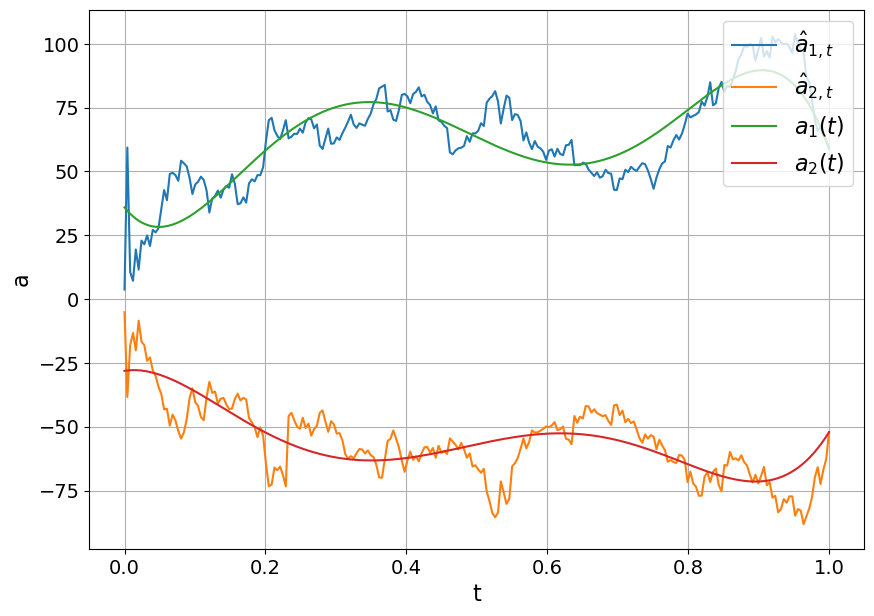

In [92]:
deg = 5

t_data = np.linspace(0, 1, T)
a_data_a1 = a_data[:,1].copy()
a_data_a2 = a_data[:,2].copy()

fit_type = 'right-sided'

a1_params = bounded_polynom_fit(t_data, a_data_a1, dim = deg, ridge_alpha = 0.0, type = fit_type)
a2_params = bounded_polynom_fit(t_data, a_data_a2, dim = deg, ridge_alpha = 0.0, type = fit_type)

a1t = bounded_polynom(t_data, a_data_a1, a1_params, type = fit_type)
a2t = bounded_polynom(t_data, a_data_a2, a2_params, type = fit_type)

a2t = correction(t_data, a2t, alpha)


plt.figure(figsize=(10, 7))

plt.plot(t_data, a_data[:,1], label = r'$\hat{a}_{1,t}$')
plt.plot(t_data, a_data[:,2], label = r'$\hat{a}_{2,t}$')

plt.plot(t_data, a1t, label = r'$a_1(t)$')
plt.plot(t_data, a2t, label = r'$a_2(t)$')

plt.xlabel('t', fontsize=16)
plt.ylabel('a', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.legend(fontsize=16, loc = 'upper right')

In [461]:
import numpy as np
from scipy.optimize import curve_fit

# Define the objective function
y0 = a_data_a2[-1]
x0 = t_data[-1]
def objective(x, c0, c1, c2, c3, c4):
    return y0 + (x - x0) * (c0 + c1 * x + c2 * x**2 + c3 * x**3 + c4 * x**4)

# Generate some dummy data

# Initial guesses for a, b, c, d
initial_guess = [1.0, 1.0, 1.0, 1.0]

# Perform curve fitting
popt, pcov = curve_fit(objective, t_data, a_data_a2)#, p0=initial_guess)

# Print the optimized parameters
print("Optimized Parameters:", popt)

Optimized Parameters: [   -8.92424158   693.76543764 -2798.94926648  5119.48967528 -2688.24600526]


In [420]:
fitted = objective(t_data, *popt)

Coefficients: [-6.34527274e-02 -5.34679699e+02  2.13239471e+03 -3.81296301e+03
  2.65737548e+03 -4.16613621e+02]


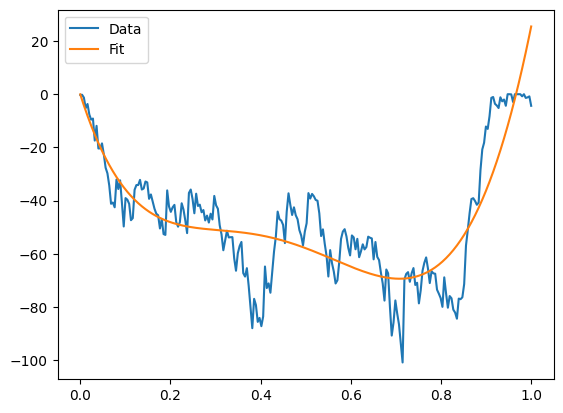

In [426]:
import numpy as np

def poly_fit(x, y, degree):
    """
    Fit a polynomial of degree 'degree' to the data (x, y)
    """
    A = np.vstack([x**i for i in range(degree+1)]).T
    coeffs, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
    return coeffs

def poly_eval(x, coeffs):
    """
    Evaluate the polynomial with coefficients 'coeffs' at points 'x'
    """
    return np.sum([coeffs[i] * x**i for i in range(len(coeffs))], axis=0)

# Example usage
x = t_data
y = a_data_a2

degree = 5  # Fit a quadratic polynomial
coeffs = poly_fit(x, y, degree)

print("Coefficients:", coeffs)

x_fit = t_data#np.linspace(1, 5, 100)
y_fit = poly_eval(x_fit, coeffs)

import matplotlib.pyplot as plt
plt.plot(x, y, label='Data')
plt.plot(x_fit, y_fit, '-', label='Fit')
plt.legend()
plt.show()

In [352]:
@jit(nopython=True, cache = True)
def mod_abs(x):
    b = 1
    #res = x * (2 / (1 + np.exp(-b * x)) - 1)
    res = x * np.tanh(b * x)
    return res

@jit(nopython=True, cache = True)
def correction(t_data, x_data, alpha):
    #alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    theta, mu, nu = alpha[0], alpha[1], alpha[2]
    sigma2 = nu**2 / (2 * theta) * (1 - np.exp(-2 * theta * t_data)) + 0.0001
    max_res = 1 / (2 * sigma2) - 0.1
    #exp_res = np.exp(-50*(max_res - x_data))
    #return 1 / (1 + exp_res) * x_data
    #max_res = 0.0
    return -(mod_abs(max_res - x_data) - max_res - x_data) / 2

In [712]:
dwt = np.random.normal(0, 1, size = (T, latent_process_tr)) * np.sqrt(1/T)

#s = np.random.randint(0, 1000000)
s = 366495
rng = np.random.RandomState(seed= s)
dwt = rng.normal(0, 1, size = (len(data), latent_process_tr)) * np.sqrt(1/len(data))

log_likelihood = np.zeros(latent_process_tr)
norm_log_data = np.zeros((T, latent_process_tr))

alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
mu = alpha2

#a1t = 1 + t_data #14 * np.sin(8 * np.pi/2 * t_data)
#a2t = 0 *  t_data #-12 * np.cos(4 * np.pi/2 * t_data)**2
#a1t = 5 * t_data #* 0
#a2t = -30 * t_data # * 0

lambda_data = m_sampler_ou(alpha, a1t, a2t, dwt, init_state)
# dt = 1/T
# for i in range(1, T):
#     a1, a2 = a1t[i], a2t[i]
#     #norm_log_data[i] = log_norm_ou_test(lambda_data[i], i/T, alpha, mu, a1, a2)
#     norm_log_data[i] = log_norm_ou(alpha, a1, a2, 1/T, lambda_data[i - 1])
#     #norm_log_data[i] = log_norm_ou(alpha, a1, a2, i/T, mu)
dt = 1/T
for i in range(T - 1, 0, -1):
    a1, a2 = a1t[i], a2t[i]
    norm_log_data[i] = log_norm_ou(alpha, a1, a2, dt, lambda_data[i - 1])
norm_log_data[0] = log_norm_ou(alpha, a1t[0], a2t[0], dt, lambda_data[0])

for k in range(0, latent_process_tr):
    copula_log_data = np.log(np.maximum(copula.np_pdf()(data.T, copula.transform(lambda_data[:,k])), 1e-100))
    g = (a1t * (lambda_data[:,k] - 0 * mu)  + a2t * (lambda_data[:,k] - 0 * mu)**2)
    log_likelihood[k] = np.sum(copula_log_data + norm_log_data[:,k] - g)
xc = np.max(log_likelihood)
avg_likelihood = np.sum(np.exp(log_likelihood - xc)) / latent_process_tr
res = np.log(avg_likelihood) + xc
print(-res)
p_jit_mlog_likelihood_ou(alpha, data, dwt, latent_process_tr, False, copula.np_pdf(), copula.transform)


-398.58947842879525


-124.20963981882639

In [748]:
def log_pdf_p(x, t, alpha, x0):
    alpha1, alpha2, alpha3 = alpha[0], alpha[1], alpha[2]
    mu = -alpha1 / alpha2
    theta = -alpha2
    nu = alpha3
    D = nu**2/2
    if t == 0:
        t = t + 0.01
    sigma2 = D / theta * (1 - np.exp(- 2 * theta * t))
    xs = (x0 - mu) * np.exp(-theta * t) + mu
    return  -1/2 * np.log(2 * np.pi * sigma2) - (x - xs)**2 / (2 * sigma2)

In [787]:
#lambda_data = np.random.uniform(-2, 2, size=(T + 1, 100000))
dwt = np.random.normal(0, 1, size=(T + 1, 10000)) * np.sqrt(1/T) 
lambda_data = p_sampler_ou(alpha, dwt)

for k in range(0, latent_process_tr):
    copula_log_data = np.log(copula.np_pdf()(pobs_data.T, copula.transform(lambda_data[:,k][1:])))
    #g = log_pdf_p(lambda_data[:,k][1:], 1/T, alpha, lambda_data[:,k][0:T])
    g = 0
    log_likelihood[k] = np.sum(copula_log_data + g)
xc = np.max(log_likelihood)
avg_likelihood = np.sum(np.exp(log_likelihood - xc)) / latent_process_tr
res = np.log(avg_likelihood) + xc
print(-res)

-370.4775664360208


In [ ]:
lp = [100, 200, 500, 1000, 5000, 10000]
alpha = np.array([-0.19788412463810046, 0.6706628689464917, -0.7031497915906386])

print(alpha)
for lp_i in lp:
    res_p_i = []
    for k in range(0, 50):
        dwt = np.random.normal(0, 1, size = (T, lp_i)) * np.sqrt(1/T)
        res = p_jit_mlog_likelihood_ou(alpha, pobs_data, dwt, lp_i, False, copula.np_pdf(), copula.transform)
        res_p_i.append(res)
    print(lp_i, np.mean(res_p_i), np.std(res_p_i) )

In [ ]:
lp = [100, 200, 500, 1000, 5000, 10000]
alpha = np.array([-0.19788412463810046, 0.6706628689464917, -0.7031497915906386])

print(alpha)
for lp_i in lp:
    res_p_i = []
    for k in range(0, 50):
        dwt = np.random.normal(0, 1, size = (T, lp_i)) * np.sqrt(1/T)
        res = m_jit_mlog_likelihood_ou(alpha, pobs_data, dwt, lp_i, 5, False, copula.np_pdf(), copula.transform)
        if np.isnan(res):
            break
        res_p_i.append(res)
    break
    print(lp_i, np.mean(res_p_i), np.std(res_p_i) )

In [640]:
#dwt = np.random.normal(0, 1, size = (T, latent_process_tr)) * np.sqrt(1/T)
# a1t = np.sin(8 * np.pi/2 * t_data)
# a2t = np.zeros(T)
p = p_sampler_ou(alpha, dwt, init_state)
m = m_sampler_ou(alpha, a1t, a2t, dwt, init_state)

In [364]:
a2t[200:]= a2t[200]

In [642]:
dt = 1/T
a1dt = []
a2dt = []
for i in range(1, T):
    a1dti, a2dti =  (a1t[i] - a1t[i - 1]) / dt, (a2t[i] - a2t[i - 1]) / dt
    a1dt.append(a1dti)
    a2dt.append(a2dti)

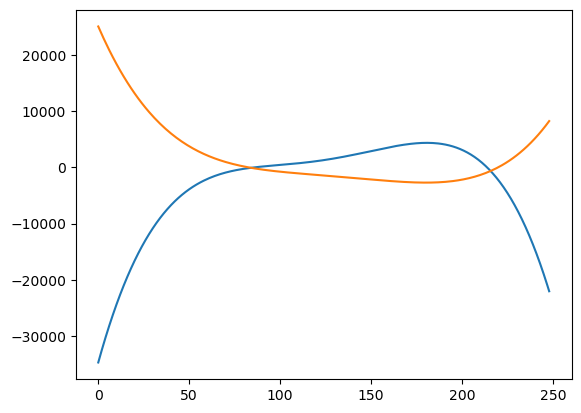

In [643]:
plt.plot(a1dt)
plt.plot(a2dt)

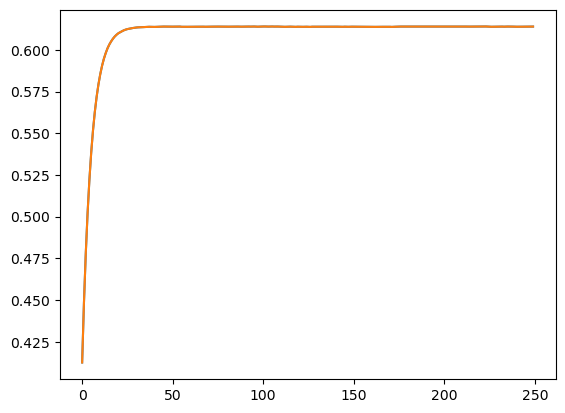

In [665]:
for i in range(0, 1):
    t = np.random.randint(0, latent_process_tr)
    plt.plot(m[:,t], label = f'm {t}')
    plt.plot(p[:,t], label = f'p {t}')

In [132]:
theta, mu, nu = alpha[0], alpha[1], alpha[2]
D = nu**2 / 2
At = []
Bt = []
mod_a1t = a2t * np.exp(-0.0000005 * a2t**2)
mod_a2t = a2t * np.exp(-0.0000005 * a2t**2)

for i in range(1, T):
    a1, a2 = mod_a1t[i], mod_a2t[i]
    a1dt, a2dt =  (mod_a1t[i] - mod_a1t[i - 1]) / dt, (mod_a2t[i] - mod_a2t[i - 1]) / dt
    t = i/T
    sigma2 = D / theta * (1 - np.exp(- 2 * theta * t))
    p = (1 - 2 * a2 * sigma2)
    sigma2w = sigma2 / p

    x0 = mu
    xs = (x0 - mu) * np.exp(-theta * t) + mu
    xsw = (xs + a1 * sigma2) / p
    sigma2dt = nu**2 - 2 * theta * sigma2
    sigma2wdt = (sigma2dt + 2 * sigma2**2 * a2dt) / p**2
    xsdt = -theta * (xs - mu)
    xswdt = (xsdt + a1 * sigma2dt + a1dt * sigma2) / p + 2 * xsw * (a2dt * sigma2 + a2 * sigma2dt) / p
    var = nu**2 / ( 1 - 2 * nu**2 * a2)
    B = nu 
    A = xswdt - (x0 - xsw) * (B**2 - sigma2wdt) / (2 * sigma2w)
    At.append(A)
    Bt.append(B)

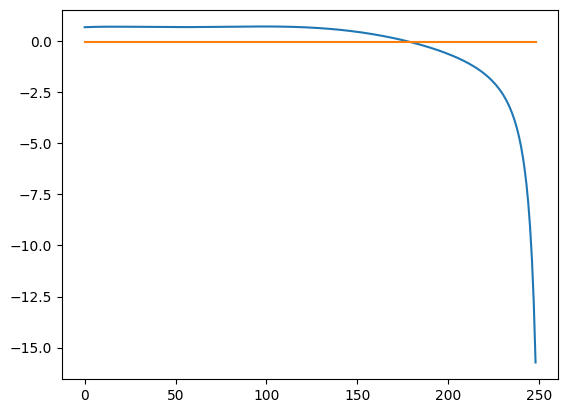

In [133]:
plt.plot(At)
plt.plot(Bt)

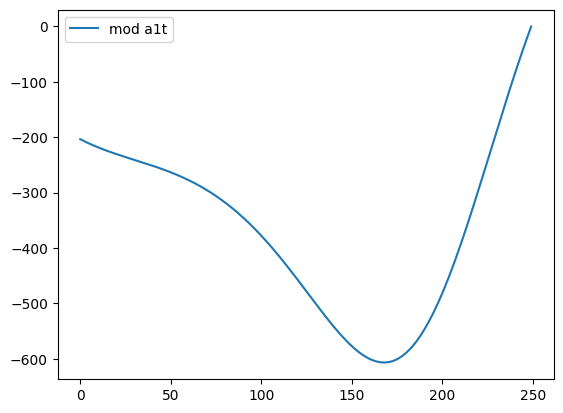

In [131]:
#plt.plot(a1t, label = 'a1t')
plt.plot(a1t * np.exp(-0.0000005 * a1t**2), label = 'mod a1t')

#plt.plot(a2t, label = 'a2t')
#plt.plot(-np.abs(a2t)**(1/2), label = 'mod a1t')

plt.legend()